In [10]:
### Important note: For some patients, they transferred to the floor in between daily CAM assessments. In those cases,
#   their last ICU day, and floor day 1, are treated as the same day. By convention, the label for that day is the last ICU
#   day, and "floor day 1" does not exist in analysis. Floor days 2-7 would then represent the 6 floor days to evaluate
#   delirium-free days.

import pandas as pd
import numpy as np
import scipy.stats
import datetime as dt
import time
import csv
import os
import shutil
import matplotlib.pyplot as plt
import datetime as dt
import math

today = dt.datetime.now().strftime("%Y-%m-%d")
#current_version = today
current_version = '2019-09-03'

# get CAM data
mad3_path = "M:/Projects/ICU_SLEEP_STUDY/data/"
subjects_path = mad3_path + "enrolled_subjects/"

cam_filename = 'M:/Projects/ICU_SLEEP_STUDY/data/cam_full_' + current_version + '.csv'
cam_df = pd.read_csv(cam_filename)

# get current data dictionary
data_dict_filename = 'M:/Projects/ICU_SLEEP_STUDY/data/data_dictionary_' + '2019-04-24' +'.csv'
dd_df_full = pd.read_csv(data_dict_filename)

# choose subjects to analyze
pre_exclude_subject_list = range(1,136)
exclusion_list = []
subject_list = [ii for ii in pre_exclude_subject_list if ii not in exclusion_list]

In [19]:
#cams_df.head(10)
cam_df.iloc[0:5,15:30]

,cam_q3,cam_q3note,cam_q4,cam_q4note,cam_q5,cam_q5note,cam_nrss,cam_nrssnote,cam_q6,cam_q6note,cam_q7,cam_q7note,cam_q8,cam_q8note,cam_q10
0,1.0,NaN,0.0,NaN,0.0,NaN,NaN,not asked,0.0,NaN,0.0,NaN,0.0,NaN,0.0
1,0.0,NaN,0.0,NaN,0.0,NaN,NaN,not asked,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2,0.0,NaN,1.0,NaN,1.0,NaN,NaN,not asked,0.0,NaN,0.0,NaN,1.0,1,0.0
3,0.0,NaN,0.0,NaN,0.0,NaN,10.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
4,0.0,NaN,0.0,NaN,0.0,NaN,8.0,NaN,1.0,2,0.0,NaN,0.0,NaN,0.0


In [15]:
# creates dictionary of CAM-S severity rating to variable in cams_df
all_cam_S_vars = ['study_id','redcap_event_name', 'camncamicu_crtdate', 'cams_1', 'cams_2', 'cams_3', 'cams_4','cams_5',
                  'cams_6','cams_7','cams_8','cams_9', 'cams_10', 'cams_total']

cam_S_dd = {'eval_datetime': 'camncamicu_crtdate', 'acute_onset':'cams_1', 'inattention':'cams_2', 'disorganized':'cams_3', 
            'LOC':'cams_4','disorientation':'cams_5', 'memory':'cams_6', 'perceptual':'cams_7', 'agitation':'cams_8', 
            'retardation':'cams_9', 'sleep_wake':'cams_10', 'CAM-S total':'cams_total'}

cam_icu_vars = ['study_id','redcap_event_name', 'camncamicu_crtdate', 'camncamicu_f1', 'camncamicu_f2', 'camncamicu_f3', 'camncamicu_f4', 'saveahaart_posneg', 'disorganized_posneg']

In [27]:
# Version 1: Calculate delirious days based on CAM-ICU
cam_icu_df = cam_df[cam_icu_vars]

icu_cam_icu_scores   = np.zeros(shape=(len(pre_exclude_subject_list),7))
floor_cam_icu_scores = np.zeros(shape=(len(pre_exclude_subject_list),7))

icu_days_included   = np.zeros(shape=(len(pre_exclude_subject_list),7))
floor_days_included = np.zeros(shape=(len(pre_exclude_subject_list),7))

for subject in subject_list:
    cam_icu_indiv_df = cam_icu_df.loc[cam_icu_df['study_id'] == str(subject)]
    icu_CAM_icu_totals = [0] * 7
    floor_CAM_icu_totals = [0] * 7
    
    last_icu_date = ''
    for index, cam in cam_icu_indiv_df.iterrows():
        
        if not (  type(cam[cam_S_dd['eval_datetime']]) is str  ):
            continue # missing data, skip
            
        eval_datetime = dt.datetime.strptime(cam[cam_S_dd['eval_datetime']], '%Y-%m-%d %H:%M')
        eval_date = eval_datetime.date()
        
        # can't calculate cam ICU
        if math.isnan(cam['camncamicu_f1']) or math.isnan(cam['camncamicu_f3']) or math.isnan(cam['camncamicu_f2']) or math.isnan(cam['camncamicu_f4']): # if score is missing, set to -1 by convention
            score = float(-1)
        else:
            altered_and_save = int(cam['camncamicu_f1']) == 1 and int(cam['camncamicu_f3']) == 1
            loc_or_disorg = int(cam['camncamicu_f2' ]) == 1 or int(cam['camncamicu_f4']) == 1
            if altered_and_save and loc_or_disorg:
                score = 1
            else:
                score = 0
        
        # set event type
        event = cam['redcap_event_name']
        event_split = event.split('_')
        event_where = event_split[0]  # 'floor' or 'icu'
        if event_where == 'additional': # this is an additional icu day, ignored here
            break # move on to next patient
            
        event_day = int(event_split[2]) # 'days 1-7'
        event_time = event_split[3] # am or pm, not needed here (yet)
        
        
        if event_where == 'icu':    # this is an icu day
            last_icu_date = eval_date
            
            if score >= float(0):
                icu_days_included[subject-1, event_day-1] = 1 # include this icu day in analysis since data exists
            
            # replace value of CAM-S for this ICU day -- use zero indexing, so subtract one
            if  score > icu_cam_icu_scores[subject-1, event_day-1]:
                icu_cam_icu_scores[subject-1, event_day-1] = score
                
        else: # this is a floor day
            
            # skip if last icu day and floor day 1 are the same
            if event_day == 1 and eval_date == last_icu_date:
                floor_days_included[subject-1, event_day-1] = 0 # not really a necessary line but is conceptually helpful
                continue # move on to next event
            
            else: 
                if score >= float(0):
                    floor_days_included[subject-1, event_day-1] = 1 # include this floor day in analysis since data exists
                    
                if  score > floor_cam_icu_scores[subject-1, event_day-1]:
                    floor_cam_icu_scores[subject-1, event_day-1] = score

# this is raw delirium days -- ignores missing data
icu_delirious_days = [0]*len(pre_exclude_subject_list)
floor_delirious_days = [0]*len(pre_exclude_subject_list)

# this is delirium-free days -- at least one observation made. If highest CAM-s below threshold, not delirious
icu_delirium_free_days = [0]*len(pre_exclude_subject_list)
floor_delirium_free_days = [0]*len(pre_exclude_subject_list)

for subject in subject_list:
    for icu_day in range(1,8): # one-index here and subtract one, in order to be consistent
        
        if icu_days_included[subject-1,icu_day-1] == 1: # there was at least one observation
            if icu_cam_icu_scores[subject-1,icu_day-1] > 0:
                icu_delirious_days[subject-1] += 1
            else:
                icu_delirium_free_days[subject-1] += 1
            
    for floor_day in range(1,8):
        
        if floor_days_included[subject-1,floor_day-1] == 1:
            if floor_cam_icu_scores[subject-1,floor_day-1] > 0:
                floor_delirious_days[subject-1] += 1
            else:
                floor_delirium_free_days[subject-1] += 1

# normalized delirium free days in tuple format
icu_delirium_free_tuples = [(0,0)]*len(pre_exclude_subject_list)
floor_delirium_free_tuples = [(0,0)]*len(pre_exclude_subject_list)

icu_delirious_tuples = [(0,0)]*len(pre_exclude_subject_list)
floor_delirious_tuples = [(0,0)]*len(pre_exclude_subject_list)

for subject in subject_list:
    observed_icu_days = sum(icu_days_included[subject-1,:])
    observed_floor_days = sum(floor_days_included[subject-1,:])
    
    icu_tuple1 = int(icu_delirium_free_days[subject-1])
    icu_delirious_tuple1 = int(icu_delirious_days[subject-1])
    icu_tuple2 = int(observed_icu_days)
    floor_tuple1 = int(floor_delirium_free_days[subject-1])
    floor_delirious_tuple1 = int(floor_delirious_days[subject-1])
    floor_tuple2 = int(observed_floor_days)
    
    icu_delirium_free_tuples[subject-1] = (icu_tuple1,icu_tuple2)
    floor_delirium_free_tuples[subject-1] = (floor_tuple1,floor_tuple2)
    
    icu_delirious_tuples[subject-1] = (icu_delirious_tuple1,icu_tuple2)
    floor_delirious_tuples[subject-1] = (floor_delirious_tuple1,floor_tuple2)
    
# calculate total included days for each

total_days_included = [0] * len(pre_exclude_subject_list)

for subject in subject_list:
    total_days = floor_delirious_days[subject-1] + icu_delirious_days[subject-1] + \
                 floor_delirium_free_days[subject-1] + icu_delirium_free_days[subject-1]
    total_days_included[subject-1] = total_days

In [13]:
# Version 2: Calculate delirious days based on raw CAM-S scores -- not normalized or augmented by nursing, and ignoring
# CAM-evaluated days in ICU beyond 7
cam_S_df = cam_df[all_cam_S_vars]

# Creates numpy arrays with the following structure: the first array is for the first seven days of the ICU (columns), 
# and represent the *highest* CAM-S total recorded for that day. The rows are subjects.
# The next list represents the first seven floor days (columns). 
# For patients who transferred in the middle of the day, the CAM-S value for floor day 1 is set to 0
icu_cam_S_scores   = np.zeros(shape=(len(pre_exclude_subject_list),7))
floor_cam_S_scores = np.zeros(shape=(len(pre_exclude_subject_list),7))

# binary whether this for each day a patient was available and data was collected
# 1= data was collected, 0= ignore this day when computing denominators for measures of delirium days
icu_days_included   = np.zeros(shape=(len(pre_exclude_subject_list),7))
floor_days_included = np.zeros(shape=(len(pre_exclude_subject_list),7))

# iterate through subjects - calculate delirium-free days
for subject in subject_list:
    cam_S_indiv_df = cam_S_df.loc[cam_S_df['study_id'] == subject]
    cam_S_indiv_df.head(10)
    
    # Creates a list with the following structure: the first list is for the first seven days of the ICU, 
    # and represent the *highest* CAM-S total recorded for that day. The next list represents the first seven
    # floor days. For patients who transferred in the middle of the day, the CAM-S value for floor day 1 is set to 0
    icu_CAM_S_totals = [0] * 7
    floor_CAM_S_totals = [0] * 7
    #num_icu_delirium_days = 0
    #num_floor_delirium_days = 0
    #avg_cam_s_total = 0
    
    #cam_s_total_series = []
    
    # assign floor 1 values to last ICU if true, and skip floor 1 data pt
    last_icu_date = ''
    #iterate through assessments
    for index, cam in cam_S_indiv_df.iterrows():
        if not (  type(cam[cam_S_dd['eval_datetime']]) is str  ):
            continue # missing data, skip
            
        eval_datetime = dt.datetime.strptime(cam[cam_S_dd['eval_datetime']], '%Y-%m-%d %H:%M')
        eval_date = eval_datetime.date()
        score = float(cam['cams_total'])
        if math.isnan(score): # if score is missing, set to -1 by convention
            score = float(-1)
        
        # set event type
        event = cam['redcap_event_name']
        event_split = event.split('_')
        event_where = event_split[0]  # 'floor' or 'icu'
        if event_where == 'additional': # this is an additional icu day, ignored here
            break # move on to next patient
            
        event_day = int(event_split[2]) # 'days 1-7'
        event_time = event_split[3] # am or pm, not needed here (yet)
        
        
        if event_where == 'icu':    # this is an icu day
            last_icu_date = eval_date
            
            if score >= float(0):
                icu_days_included[subject-1, event_day-1] = 1 # include this icu day in analysis since data exists
            
            # replace value of CAM-S for this ICU day -- use zero indexing, so subtract one
            if  score > icu_cam_S_scores[subject-1, event_day-1]:
                icu_cam_S_scores[subject-1, event_day-1] = score
                
        else: # this is a floor day
            
            # skip if last icu day and floor day 1 are the same
            if event_day == 1 and eval_date == last_icu_date:
                floor_days_included[subject-1, event_day-1] = 0 # not really a necessary line but is conceptually helpful
                continue # move on to next event
            
            else: 
                if score >= float(0):
                    floor_days_included[subject-1, event_day-1] = 1 # include this floor day in analysis since data exists
                    
                if  score > floor_cam_S_scores[subject-1, event_day-1]:
                    floor_cam_S_scores[subject-1, event_day-1] = score
            

# CAM scores are tabulated. Compute delirium-free days
CAM_S_thresh = 3 # delirium is anything greater than this. Equal to is non-delirious

# this is raw delirium days -- ignores missing data
icu_delirious_days = [0]*len(pre_exclude_subject_list)
floor_delirious_days = [0]*len(pre_exclude_subject_list)

# this is delirium-free days -- at least one observation made. If highest CAM-s below threshold, not delirious
icu_delirium_free_days = [0]*len(pre_exclude_subject_list)
floor_delirium_free_days = [0]*len(pre_exclude_subject_list)

for subject in subject_list:
    for icu_day in range(1,8): # one-index here and subtract one, in order to be consistent
        
        if icu_days_included[subject-1,icu_day-1] == 1: # there was at least one observation
            if icu_cam_S_scores[subject-1,icu_day-1] > CAM_S_thresh:
                icu_delirious_days[subject-1] += 1
            else:
                icu_delirium_free_days[subject-1] += 1
            
    for floor_day in range(1,8):
        
        if floor_days_included[subject-1,floor_day-1] == 1:
            if floor_cam_S_scores[subject-1,floor_day-1] > CAM_S_thresh:
                floor_delirious_days[subject-1] += 1
            else:
                floor_delirium_free_days[subject-1] += 1

# normalized delirium free days in tuple format
icu_delirium_free_tuples = [(0,0)]*len(pre_exclude_subject_list)
floor_delirium_free_tuples = [(0,0)]*len(pre_exclude_subject_list)

icu_delirious_tuples = [(0,0)]*len(pre_exclude_subject_list)
floor_delirious_tuples = [(0,0)]*len(pre_exclude_subject_list)

for subject in subject_list:
    observed_icu_days = sum(icu_days_included[subject-1,:])
    observed_floor_days = sum(floor_days_included[subject-1,:])
    
    icu_tuple1 = int(icu_delirium_free_days[subject-1])
    icu_delirious_tuple1 = int(icu_delirious_days[subject-1])
    icu_tuple2 = int(observed_icu_days)
    floor_tuple1 = int(floor_delirium_free_days[subject-1])
    floor_delirious_tuple1 = int(floor_delirious_days[subject-1])
    floor_tuple2 = int(observed_floor_days)
    
    icu_delirium_free_tuples[subject-1] = (icu_tuple1,icu_tuple2)
    floor_delirium_free_tuples[subject-1] = (floor_tuple1,floor_tuple2)
    
    icu_delirious_tuples[subject-1] = (icu_delirious_tuple1,icu_tuple2)
    floor_delirious_tuples[subject-1] = (floor_delirious_tuple1,floor_tuple2)


In [14]:
print(icu_delirium_free_days)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


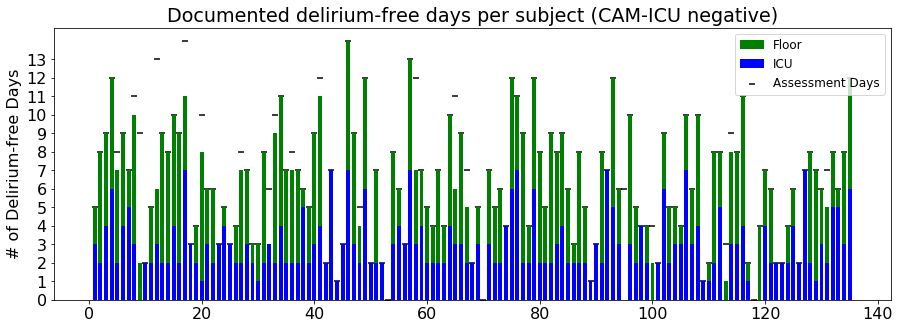

In [28]:
# Version 1: delirium-free days

N = 135
ind = np.arange(1,N+1)    # the x locations for the groups
width = .7      # the width of the bars: can also be len(x) sequence

fig=plt.figure(figsize=(15, 5))
p2 = plt.bar(ind, icu_delirium_free_days, width, color="blue")
p1 = plt.bar(ind, floor_delirium_free_days, width, bottom=icu_delirium_free_days, color="green")

p_max = plt.scatter(ind, total_days_included, marker = '_', color='black')

plt.ylabel('# of Delirium-free Days')
plt.title('Documented delirium-free days per subject (CAM-ICU negative)')
#plt.xticks(ind)
plt.yticks(np.arange(0, 14))
plt.rcParams.update({'font.size': 16})
plt.legend((p1[0], p2[0], p_max), ('Floor', 'ICU', 'Assessment Days'), loc = 'best', prop={'size': 12} )

#plt.savefig(mad3_path + 'ICU_delirium_free_days_09032019.png')
plt.show()

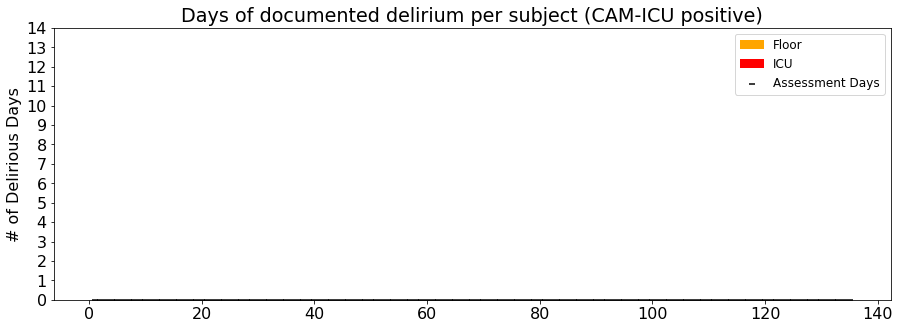

In [16]:

N = 135
ind = np.arange(1,N+1)    # the x locations for the groups
width = .7      # the width of the bars: can also be len(x) sequence

fig=plt.figure(figsize=(15, 5))
p1 = plt.bar(ind, floor_delirious_days, width, bottom= icu_delirious_days, color="orange")
p2 = plt.bar(ind, icu_delirious_days, width, color="red")
p_max = plt.scatter(ind, total_days_included, marker = '_', color='black')

plt.ylabel('# of Delirious Days')
plt.title('Days of documented delirium per subject (CAM-ICU positive)')
#plt.xticks(ind)
plt.yticks(np.arange(0, 15))
plt.rcParams.update({'font.size': 16})
plt.legend((p1[0], p2[0], p_max), ('Floor', 'ICU', 'Assessment Days'), loc = 'best', prop={'size': 12} )

#plt.savefig(mad3_path + 'delirious_days_04242019.png')
plt.show()

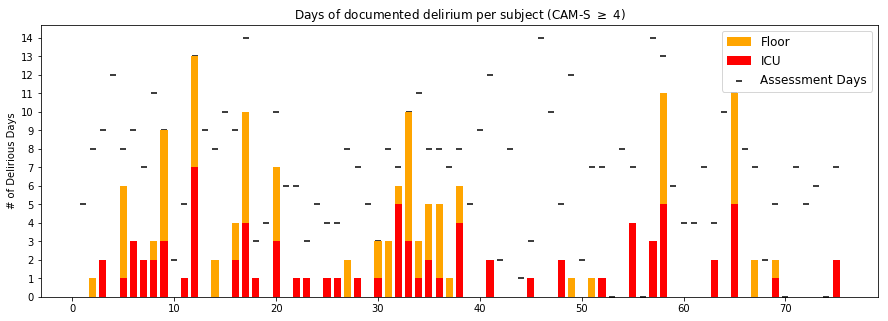

In [16]:
# Version 2: Plot number of delirious days


N = 75
ind = np.arange(1,N+1)    # the x locations for the groups
width = .7      # the width of the bars: can also be len(x) sequence

fig=plt.figure(figsize=(15, 5))
p1 = plt.bar(ind, floor_delirious_days, width, bottom= icu_delirious_days, color="orange")
p2 = plt.bar(ind, icu_delirious_days, width, color="red")
p_max = plt.scatter(ind, total_days_included, marker = '_', color='black')

plt.ylabel('# of Delirious Days')
plt.title('Days of documented delirium per subject (CAM-S $\geq$ 4)')
#plt.xticks(ind)
plt.yticks(np.arange(0, 15))
plt.rcParams.update({'font.size': 16})
plt.legend((p1[0], p2[0], p_max), ('Floor', 'ICU', 'Assessment Days'), loc = 'best', prop={'size': 12} )

plt.savefig(mad3_path + 'delirious_days_04022019.png')
plt.show()

[3, 2, 2, 6, 1, 1, 3, 2, 0, 2, 1, 0, 2, 2, 4, 0, 3, 2, 2, 0, 3, 1, 2, 4, 3, 1, 2, 2, 3, 0, 2, 0, 0, 3, 0, 1, 2, 1, 2, 3, 3, 2, 7, 1, 2, 7, 3, 1, 6, 2, 2, 2, 0, 3, 0, 0, 4, 1, 4, 2, 2, 2, 0, 4, 0, 3, 2, 2, 2, 0, 3, 2, 2, 0, 4]

[2, 5, 5, 6, 1, 5, 2, 6, 0, 0, 3, 0, 7, 4, 6, 5, 1, 0, 2, 3, 3, 4, 0, 1, 0, 2, 4, 4, 2, 0, 3, 1, 0, 5, 3, 2, 4, 1, 3, 6, 7, 0, 1, 0, 0, 7, 7, 2, 5, 0, 4, 4, 0, 5, 3, 0, 7, 1, 2, 2, 2, 5, 2, 6, 0, 5, 3, 0, 1, 0, 4, 3, 4, 0, 1]


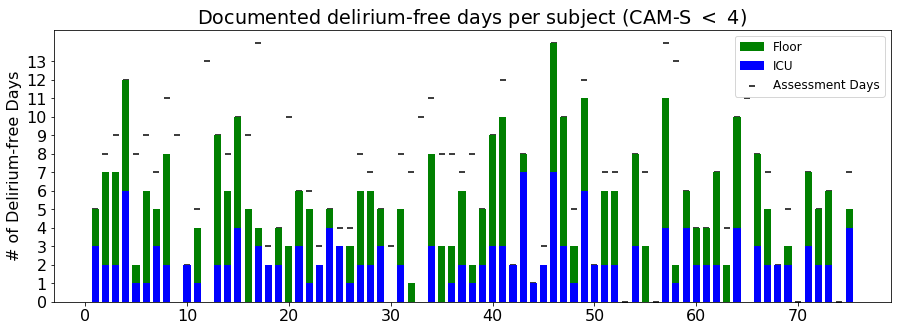

In [18]:
# Version 2: Plot number of delirium-free days
print(icu_delirium_free_days)
print('')
print(floor_delirium_free_days)

N = 75
ind = np.arange(1,N+1)    # the x locations for the groups
width = .7      # the width of the bars: can also be len(x) sequence

fig=plt.figure(figsize=(15, 5))
p2 = plt.bar(ind, icu_delirium_free_days, width, color="blue")
p1 = plt.bar(ind, floor_delirium_free_days, width, bottom=icu_delirium_free_days, color="green")

p_max = plt.scatter(ind, total_days_included, marker = '_', color='black')

plt.ylabel('# of Delirium-free Days')
plt.title('Documented delirium-free days per subject (CAM-S $<$ 4)')
#plt.xticks(ind)
plt.yticks(np.arange(0, 14))
plt.rcParams.update({'font.size': 16})
plt.legend((p1[0], p2[0], p_max), ('Floor', 'ICU', 'Assessment Days'), loc = 'best', prop={'size': 12} )

plt.savefig(mad3_path + 'delirium_free_days_04022019.png')
plt.show()

In [29]:
### ICU cam delirium free

print(icu_delirium_free_tuples)
print('')
print(floor_delirium_free_tuples)

d = []
for subject in subject_list:
    ID = str(subject)
    icu_tup = icu_delirium_free_tuples[subject-1]
    icu_delirious_tup = icu_delirious_tuples[subject-1]
    icu_delirium_free_str = str(icu_tup[0]) + '/' + str(icu_tup[1])
    icu_delirious_str = str(icu_delirious_tup[0]) + '/' + str(icu_delirious_tup[1])
    floor_tup = floor_delirium_free_tuples[subject-1]
    floor_delirious_tup = floor_delirious_tuples[subject-1]
    floor_delirium_free_str = str(floor_tup[0]) + '/' + str(floor_tup[1])
    floor_delirious_str = str(floor_delirious_tup[0]) + '/' + str(floor_delirious_tup[1])
    d.append({'Study ID': ID, 'ICU delirium-free days': icu_delirium_free_str,
              'Floor delirium-free days': floor_delirium_free_str, 'ICU delirious days':icu_delirious_str,
              'Floor delirious days':floor_delirious_str})
    
cam_s_output_df = pd.DataFrame(d)
cam_s_output_path = mad3_path + '/CAM-ICU-del-free-2019-09-03.xlsx'
cols = ['Study ID', 'ICU delirious days', 'Floor delirious days', 'ICU delirium-free days','Floor delirium-free days']
cam_s_output_df.to_excel(cam_s_output_path, index = None, columns=cols)

[(3, 3), (2, 2), (4, 4), (6, 6), (2, 2), (4, 4), (5, 5), (3, 4), (0, 3), (2, 2), (2, 2), (3, 7), (2, 2), (2, 2), (4, 4), (2, 2), (7, 7), (3, 3), (2, 2), (1, 3), (3, 3), (2, 2), (3, 3), (4, 4), (3, 3), (2, 2), (2, 2), (3, 3), (2, 2), (1, 1), (2, 2), (3, 5), (2, 3), (4, 4), (2, 2), (2, 2), (2, 2), (5, 5), (2, 2), (3, 3), (4, 5), (2, 2), (7, 7), (1, 1), (3, 3), (7, 7), (3, 3), (2, 3), (6, 6), (2, 2), (2, 2), (2, 2), (0, 0), (3, 3), (4, 4), (3, 3), (7, 7), (3, 5), (4, 4), (2, 2), (2, 2), (2, 2), (2, 2), (4, 4), (3, 5), (3, 3), (2, 2), (2, 2), (3, 3), (0, 0), (3, 3), (2, 2), (2, 2), (4, 4), (6, 6), (7, 7), (2, 2), (2, 2), (6, 6), (2, 2), (2, 2), (2, 2), (3, 3), (4, 4), (2, 2), (2, 2), (2, 2), (2, 2), (1, 1), (3, 3), (2, 2), (7, 7), (5, 5), (3, 3), (0, 6), (3, 3), (2, 2), (4, 4), (2, 2), (0, 2), (2, 2), (6, 6), (2, 2), (3, 3), (3, 3), (7, 7), (3, 3), (4, 4), (1, 1), (1, 1), (2, 2), (5, 5), (0, 1), (3, 4), (3, 3), (4, 4), (1, 1), (0, 0), (0, 0), (4, 4), (2, 2), (2, 2), (2, 2), (2, 2), (4, 4),

In [20]:
### delirium-free ; ignore for now. We are doing days of delirium

print(icu_delirium_free_tuples)
print('')
print(floor_delirium_free_tuples)

d = []
for subject in subject_list:
    ID = str(subject)
    icu_tup = icu_delirium_free_tuples[subject-1]
    icu_delirious_tup = icu_delirious_tuples[subject-1]
    icu_delirium_free_str = str(icu_tup[0]) + '/' + str(icu_tup[1])
    icu_delirious_str = str(icu_delirious_tup[0]) + '/' + str(icu_delirious_tup[1])
    floor_tup = floor_delirium_free_tuples[subject-1]
    floor_delirious_tup = floor_delirious_tuples[subject-1]
    floor_delirium_free_str = str(floor_tup[0]) + '/' + str(floor_tup[1])
    floor_delirious_str = str(floor_delirious_tup[0]) + '/' + str(floor_delirious_tup[1])
    d.append({'Study ID': ID, 'ICU delirium-free days': icu_delirium_free_str,
              'Floor delirium-free days': floor_delirium_free_str, 'ICU delirious days':icu_delirious_str,
              'Floor delirious days':floor_delirious_str})
    
cam_s_output_df = pd.DataFrame(d)
cam_s_output_path = mad3_path + '/CAM-S-del-free-2019-04-24.xlsx'
cols = ['Study ID', 'ICU delirious days', 'Floor delirious days', 'ICU delirium-free days','Floor delirium-free days']
cam_s_output_df.to_excel(cam_s_output_path, index = None, columns=cols)

[(3, 3), (2, 2), (2, 4), (6, 6), (1, 2), (1, 4), (3, 5), (2, 4), (0, 3), (2, 2), (1, 2), (0, 7), (2, 2), (2, 2), (4, 4), (0, 2), (3, 7), (2, 3), (2, 2), (0, 3), (3, 3), (1, 2), (2, 3), (4, 4), (3, 4), (1, 2), (2, 2), (2, 3), (3, 3), (0, 1), (2, 2), (0, 5), (0, 3), (3, 4), (0, 2), (1, 2), (2, 2), (1, 5), (2, 2), (3, 3), (3, 5), (2, 2), (7, 7), (1, 1), (2, 3), (7, 7), (3, 3), (1, 3), (6, 6), (2, 2), (2, 2), (2, 3), (0, 0), (3, 3), (0, 4), (0, 0), (4, 7), (1, 6), (4, 4), (2, 2), (2, 2), (2, 2), (0, 2), (4, 4), (0, 5), (3, 3), (2, 2), (2, 2), (2, 3), (0, 0), (3, 3), (2, 2), (2, 2), (0, 0), (4, 6)]

[(2, 2), (5, 6), (5, 5), (6, 6), (1, 6), (5, 5), (2, 2), (6, 7), (0, 6), (0, 0), (3, 3), (0, 6), (7, 7), (4, 6), (6, 6), (5, 7), (1, 7), (0, 0), (2, 2), (3, 7), (3, 3), (4, 4), (0, 0), (1, 1), (0, 0), (2, 2), (4, 6), (4, 4), (2, 2), (0, 2), (3, 6), (1, 2), (0, 7), (5, 7), (3, 6), (2, 6), (4, 5), (1, 3), (3, 3), (6, 6), (7, 7), (0, 0), (1, 1), (0, 0), (0, 0), (7, 7), (7, 7), (2, 2), (5, 6), (0, 0